## 0. PyTorch Bilgisayarlı Görü (Computer Vision) Kütüphaneleri

* `torchvision` - PyTorch için temel
bilgisayarlı görü alan kütüphanesidir.

* `torchvision.datasets` - Bilgisayarlı görüye yönelik popüler hazır veri kümelerini ve veri yükleme işlevlerini barındırır.

* `torchvision.models` - Kendi problemlerinize uyarlayabileceğiniz önceden eğitilmiş (pretrained) bilgisayarlı görü mimarilerini sunar.

* `torchvision.transforms` - Görsel verilerinizi modellerle kullanılmaya uygun hale getirmek için dönüştürme (döndürme, kırpma, tensöre çevirme, normalize etme vb.) işlevlerini içerir.

* `torch.utils.data.Dataset` - PyTorch'un temel veri kümesi (dataset) sınıfıdır.

* `torch.utils.data.DataLoader` - Veri kümesi üzerinde mini-batch'ler halinde gezinmeyi sağlayan Python yinelenebilir (iterable) nesnesini oluşturur.








In [ ]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor, Lambda

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


Eski sürümde (v1) görseli 90 derece döndürdüğünüzde resim döner ancak kırmızı kutu yatay haliyle havada asılı kalırdı (nesneyi kaçırırdı). `transforms.v2` ise görselin döndüğünü anlayıp köşe koordinatlarını ($x_1, y_1, x_2, y_2$) otomatik olarak yeniden hesaplar ve kutuyu yeni nesne sınırlarına oturtur.
 * Rastgele siyah bir tuval üzerine beyaz bir "nesne" ve etrafına kırmızı bir kutu tanımlanmış, ardından 90 derece döndürülmüştür:

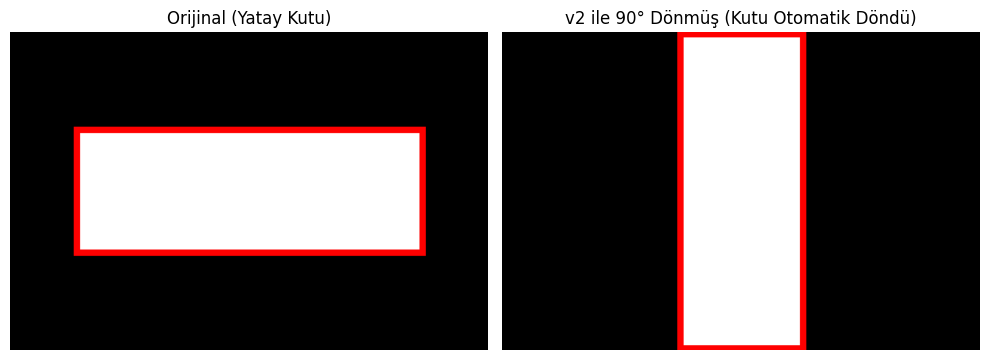

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as v2
from torchvision import tv_tensors
from torchvision.utils import draw_bounding_boxes

# 1. 200x300 boyutunda yapay bir görsel üretelim (H=200, W=300)
H, W = 200, 300
img = torch.zeros(3, H, W, dtype=torch.uint8)

# Görselin içine "köpek" niyetine beyaz bir dikdörtgen çizelim
img[:, 60:140, 40:260] = 255

# 2. Bu nesneyi saran Bounding Box tanımlayalım [xmin, ymin, xmax, ymax]
boxes = tv_tensors.BoundingBoxes(
    [[40, 60, 260, 140]], format="XYXY", canvas_size=(H, W)
)

# 3. v2 ile 90 Derece Döndürme Pipeline'ı kuralım
rotate_transform = v2.RandomRotation(degrees=(90, 90))

# HEM resmi HEM kutuyu tek satırda döndürelim:
img_rot, boxes_rot = rotate_transform(img, boxes)

# 4. Kutuları görsellerin üzerine çizdirip yan yana basalım
img_with_box = draw_bounding_boxes(img, boxes, colors="red", width=4)
img_rot_with_box = draw_bounding_boxes(
    img_rot, boxes_rot, colors="red", width=4
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_with_box.permute(1, 2, 0))
axs[0].set_title("Orijinal (Yatay Kutu)")
axs[0].axis("off")

axs[1].imshow(img_rot_with_box.permute(1, 2, 0))
axs[1].set_title("v2 ile 90° Dönmüş (Kutu Otomatik Döndü)")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## 1. Getting a dataset





In [ ]:
from numpy import test
# Setup training data

train_data = datasets.FashionMNIST(
    root="data", # veri nereye kaydedilecek?
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.4MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
# 1. Train ve test setinden ilk örnekleri çek
train_image, train_label = train_data[0]
test_image, test_label = test_data[0]

In [ ]:
train_image, train_label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
# Check the shape of our image
image.shape, label

(torch.Size([1, 28, 28]), 9)

#### Visualizing our data

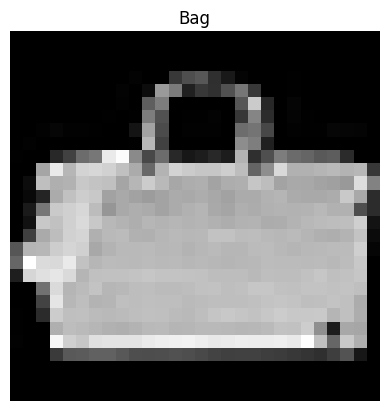

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

image, label = train_data[99]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
plt.show()

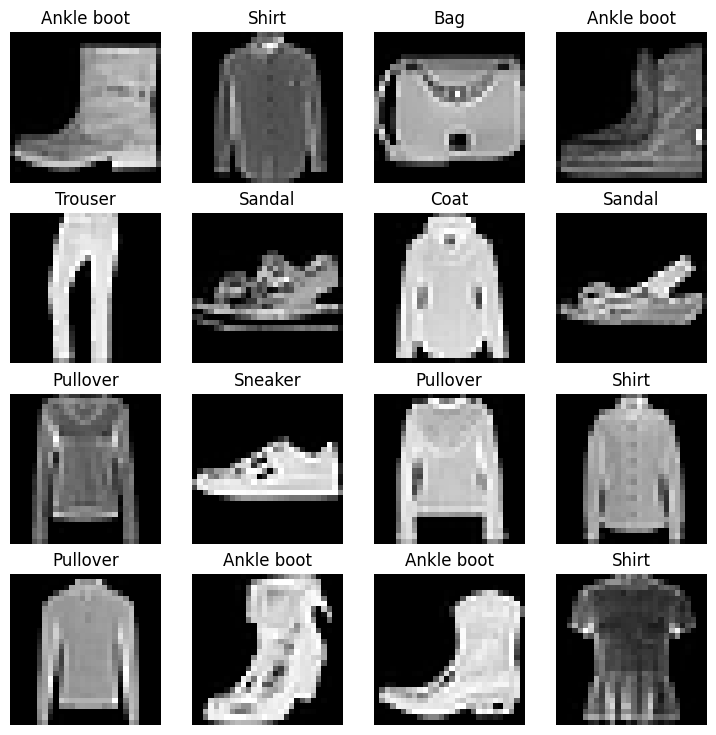

In [ ]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader


In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Trun datasets into iterables (batches)

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x79864848bcb0>,
 <torch.utils.data.dataloader.DataLoader at 0x7986451f7610>)

In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
# Let's check out what what we have created
print(f"Dataloader: {train_dataloader}\nLength: {len(train_dataloader)}\nType: {type(train_dataloader)}")

Dataloader: <torch.utils.data.dataloader.DataLoader object at 0x79864848bcb0>
Length: 1875
Type: <class 'torch.utils.data.dataloader.DataLoader'>


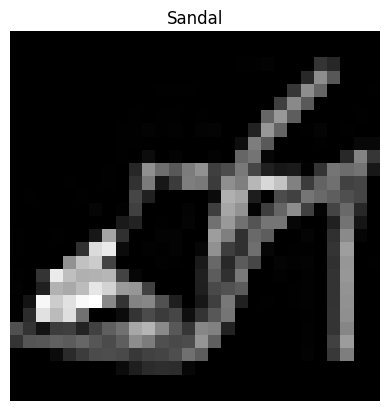

In [ ]:
# Show a sample
image, label = next(iter(train_dataloader))
plt.imshow(image[0].squeeze(), cmap="gray")
plt.title(class_names[label[0]])
plt.axis(False)
plt.show()

## 3. Model 0: Build a baseline model

In [ ]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]
print(f"Shape of x before flattening: {x.shape}")

# Flatten x
x_flattened = flatten_model(x)
print(f"Shape of x after flattening: {x_flattened.shape}")

Shape of x before flattening: torch.Size([1, 28, 28])
Shape of x after flattening: torch.Size([1, 784])


In [ ]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)

# Setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=28*28,
                               hidden_units=10,
                               output_shape=len(class_names)).to('cpu')
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
device = next(model_0.parameters()).device
print(device)

cpu


In [ ]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics

In [ ]:
# Calculate accuracy and f1 score
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
import requests
from pathlib import Path

# Download helper function from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
# Import accuracy metric
from helper_functions import accuracy_fn

# Setup loss, optimizer and evaluation metrics
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### 3.2 Creating a function to time our experiment

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time.

  Args:
    start (float): Start time of computation (preferred in timeit format).
    end (float): End time of computation.
    device ([optional]): Device that compute is running on.
  """
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [ ]:
start_time = timer()
# some code
end_time = timer()
print_train_time(start=start_time, end=end_time, device=None)

Train time on None: 0.000 seconds


6.630400002904935e-05

### 3.3 Creating a training loop and training a model on batches of data...

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate train loss.
3. Loop through testing batches, perform testing steps, calculate the loss.
4. Print out what's happening.
5. Time it all.

In [ ]:
#Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs
epochs = 3

train_loss_values = []
test_loss_values = []
test_acc_values = []
epoch_count = []

# Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  ### Training
  train_loss = 0
  # Add a loop to loop through training batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calculate the loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Print out how many samples have been seen
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  # Divide total train loss by length of train dataloader (average loss per batch per epoch)
  train_loss /= len(train_dataloader)

  ### Testing
  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    # Loop through testing batches
    for X, y in test_dataloader:
      # 1. Forward pass
      test_pred = model_0(X)

      # 2. Calculate the loss (accumulates loss per batch)
      test_loss += loss_fn(test_pred, y)

      # 3. Calculate accuracy
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    # Calculate the test loss average per batch
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    # train_loss_values
    train_loss_values.append(train_loss.item())
    test_loss_values.append(test_loss.item())
    test_acc_values.append(test_acc)
    epoch_count.append(epoch)

  # Print out what's happening
  print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")


# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43
Train time on cpu: 28.843 seconds


## Make predictions and get Model 0 results

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  '''Returns a dictionary containing the results of model predicting on data_loader.'''
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {'model_name': model.__class__.__name__,
            'model_loss': loss.item(),
            'model_acc': acc}

# Calculate model 0 resulst on test dataset
model_0_results = eval_model(model=model_0,
                              data_loader=test_dataloader,
                              loss_fn=loss_fn,
                              accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [ ]:
pip install -q torchmetrics mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.2 MB/s eta 0:00:00


Tahminler yapılıyor:   0%|          | 0/313 [00:00<?, ?it/s]

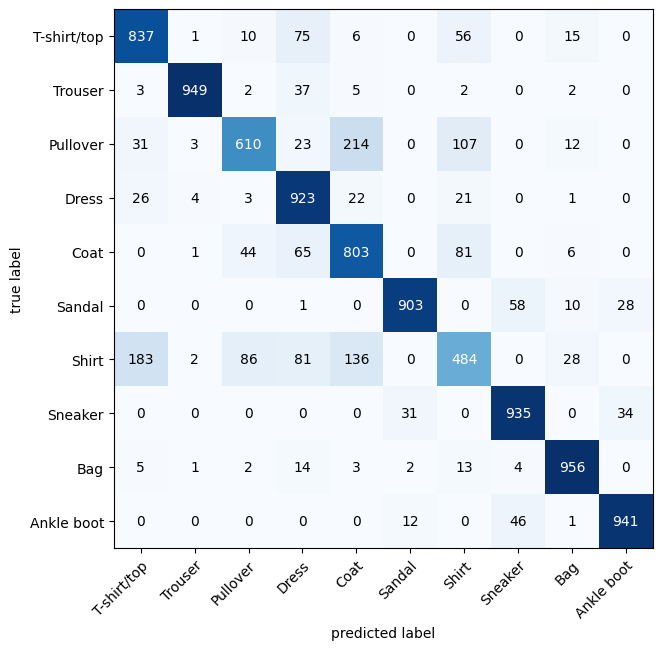

In [ ]:
# ConfusionMatrix
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
import torch
from torchmetrics import ConfusionMatrix
from tqdm.auto import tqdm

# 1. Tüm test verisi için tahminleri topla
y_preds = []
model_0.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Tahminler yapılıyor"):
        # İleri yayılım
        y_logits = model_0(X)
        # Logit -> En yüksek skorlu sınıf indeksi
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
        # Tensörleri CPU'ya alıp listeye ekle
        y_preds.append(y_pred.cpu())

# Batch listesini tek bir uzun tensöre birleştir: [10000]
y_pred_tensor = torch.cat(y_preds)

# 2. Confusion Matrix nesnesini kur ve matrisi hesapla
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

# 3. Görselleştir
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7),
)
plt.show()

## 5. Setup device agnostic-code (for using a GPU if there is one)

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
torch.cuda.is_available()

False

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cpu'

In [ ]:
# 1. Modeli oluştur ve ÖNCE cihaza gönder
model_00 = FashionMNISTModelV0(
    input_shape=784, hidden_units=10, output_shape=10
).to(device)

# 2. Optimizer'ı model cihaza geçtikten SONRA model_00 ile kur
optimizer = torch.optim.SGD(params=model_00.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.SGD(params=model_00.parameters(), lr=0.1)

In [ ]:
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    ### Training
    train_loss = 0
    model_00.train()  # <-- Her epoch başında eğitim modunu garantiye alın

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model_00(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    ### Testing
    test_loss, test_acc = 0, 0
    model_00.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            test_pred = model_00(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

        train_loss_values.append(train_loss.item())
        test_loss_values.append(test_loss.item())
        test_acc_values.append(
            test_acc.item() if hasattr(test_acc, "item") else test_acc
        )
        epoch_count.append(epoch)

    print(
        f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc:"
        f" {test_acc:.2f}%"
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.59494 | Test loss: 0.56604, Test acc: 80.79%
Epoch: 1
-------
Train loss: 0.47741 | Test loss: 0.49347, Test acc: 82.32%
Epoch: 2
-------
Train loss: 0.45669 | Test loss: 0.48287, Test acc: 83.50%


## 6. Model 1: Building a better model with non-linearity

In [ ]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)

In [ ]:
# Create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names)
).to(device)

In [ ]:
next(model_1.parameters()).device

device(type='cpu')

### 6.1 Setup loss, optimizer and evaluation metrics

In [ ]:
from helper_functions import accuracy_fn

# Setup loss, optimizer and evaluation metrics
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

### 6.2 Functionizing training and evaluation/testing loops

In [ ]:
# Set the number of epochs
epochs = 3

train_loss_values = []
train_acc_values = []
test_loss_values = []
test_acc_values = []
epoch_count = []


for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    ### Training
    train_loss, train_acc = 0, 0

    model_1.train()  # <-- Her epoch başında eğitim modunu garantiye alın

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model_1(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    ### Testing
    test_loss, test_acc = 0, 0
    model_1.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            test_pred = model_1(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

        train_loss_values.append(train_loss.item())
        test_loss_values.append(test_loss.item())
        train_loss_values.append(train_loss.item())
        train_acc_values.append(
            train_acc.item() if hasattr(train_acc, "item") else train_acc
        )
        test_loss_values.append(test_loss.item())
        test_acc_values.append(
            test_acc.item() if hasattr(test_acc, "item") else test_acc
        )
        epoch_count.append(epoch)

    print(
        f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc:"
        f" {test_acc:.2f}%"
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.64429 | Test loss: 0.54185, Test acc: 80.68%
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.47849 | Test loss: 0.46595, Test acc: 83.53%
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.44442 | Test loss: 0.49056, Test acc: 83.20%


In [ ]:
torch.manual_seed(42)
def eval_mode_1(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  '''Returns a dictionary containing the results of model predicting on data_loader.'''
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {'model_name': model.__class__.__name__,
            'model_loss': loss.item(),
            'model_acc': acc}

In [ ]:
model_1_results = eval_mode_1(model=model_1,
                              data_loader=test_dataloader,
                              loss_fn=loss_fn,
                              accuracy_fn=accuracy_fn)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.4905567467212677,
 'model_acc': 83.19688498402556}

## 7. Model 2: Building a CNN

In [ ]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
  '''
  Model architecture that replicates the TinyVGG architecture.

  Args:
    input_shape: An integer indicating number of input channels.
    hidden_units: An integer indicating number of hidden units between layers.
    output_shape: An integer indicating number of output units.
  '''
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                      stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [ ]:
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 7.1 Stepping through `nn.Conv2d()`

In [ ]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

print(f"Shape of test image: {images.shape}")
print(f"Shape of single color channel of test image: {test_image.shape}")
print(f"Shape of single color channel of test image after unsqueeze: {test_image}")

Shape of test image: torch.Size([32, 3, 64, 64])
Shape of single color channel of test image: torch.Size([3, 64, 64])
Shape of single color channel of test image after unsqueeze: tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [

In [ ]:
torch.manual_seed(42)
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=1)

# Pass the data through the convolutional layer
conv_output = conv_layer(test_image.unsqueeze(dim=0))
conv_output.shape

torch.Size([1, 10, 64, 64])

### 7.2 Stepping through `nn.MaxPool2d()`

In [ ]:
# Print out original image shape without unsqueezed dimension
print(f"Shape of test image: {test_image.shape}")
print(f"Shape of test image after unsqueeze: {test_image.unsqueeze(dim=0).shape}")

# Create a maxpool2d layer
maxpool_layer = nn.MaxPool2d(kernel_size=2,
                             stride=2)

# Pass the data through the maxpool layer
maxpool_output = maxpool_layer(test_image.unsqueeze(dim=0))
maxpool_output.shape

Shape of test image: torch.Size([3, 64, 64])
Shape of test image after unsqueeze: torch.Size([1, 3, 64, 64])


torch.Size([1, 3, 32, 32])

In [ ]:
torch.manual_seed(42)
# Create a random tensor with a similar number of dimensions to our images
random_tensor = torch.rand(size=(1, 1, 2, 2))

# Create a max pool layer
maxpool_layer = nn.MaxPool2d(kernel_size=2,
                             stride=2)

# Pass the data through the maxpool layer
maxpool_output = maxpool_layer(random_tensor)

print(f"Random tensor: \n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")
print(f"Output tensor: \n{maxpool_output}")
print(f"Output tensor shape: {maxpool_output.shape}")

Random tensor: 
tensor([[[[0.8823, 0.9150],
          [0.3829, 0.9593]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])
Output tensor: 
tensor([[[[0.9593]]]])
Output tensor shape: torch.Size([1, 1, 1, 1])


In [ ]:
test_tensor = torch.randn(size=(1, 1, 28, 28))

In [ ]:
print("Modelin olduğu yer:", next(model_2.parameters()).device)
print("Tensörün olduğu yer:", test_tensor.device)

Modelin olduğu yer: cpu
Tensörün olduğu yer: cpu


In [ ]:
model_2(test_tensor)

tensor([[ 0.0403, -0.0905,  0.0655, -0.0386,  0.0060,  0.0168,  0.0116,  0.0094,
         -0.0144, -0.0078]], grad_fn=<AddmmBackward0>)

In [ ]:
# 1. Logitleri % olasılığa dönüştürmek (Toplamları 1.0 olur):
olasiliklar = torch.softmax(model_2(test_tensor), dim=1)

# 2. En yüksek skorlu sınıfın etiketini (indeksini) seçmek:
tahmin_edilen_etiket = torch.argmax(olasiliklar, dim=1)  # Çıktı: tensor([2])

In [ ]:
tahmin_edilen_etiket, olasiliklar

(tensor([2]),
 tensor([[0.1041, 0.0913, 0.1067, 0.0962, 0.1005, 0.1016, 0.1011, 0.1009, 0.0985,
          0.0992]], grad_fn=<SoftmaxBackward0>))

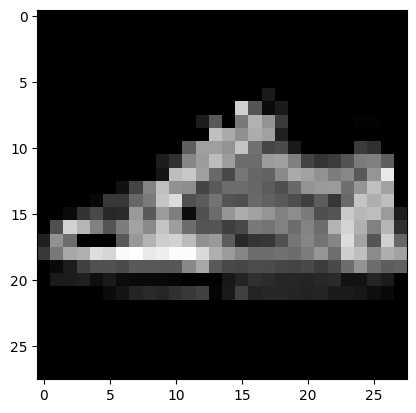

In [ ]:
plt.imshow(image[3].squeeze(), cmap='gray')

In [ ]:
image[3].unsqueeze(dim=0).shape

torch.Size([1, 1, 28, 28])

In [ ]:
model_2(image[3].unsqueeze(dim=0))

tensor([[ 0.0310, -0.0648,  0.0515, -0.0246, -0.0160,  0.0159, -0.0030, -0.0047,
          0.0255,  0.0088]], grad_fn=<AddmmBackward0>)

In [ ]:
model_2(image[3].unsqueeze(dim=0))

# 1. Logitleri % olasılığa dönüştürmek (Toplamları 1.0 olur):
olasiliklar_2 = torch.softmax(model_2(image[3].unsqueeze(dim=0)),
                            dim=1)

# 2. En yüksek skorlu sınıfın etiketini (indeksini) seçmek:
tahmin_edilen_etiket_2 = torch.argmax(olasiliklar_2,
                                    dim=1)  # Çıktı: tensor([2])

olasiliklar_2, tahmin_edilen_etiket_2

(tensor([[0.1029, 0.0935, 0.1050, 0.0973, 0.0982, 0.1014, 0.0995, 0.0993, 0.1023,
          0.1006]], grad_fn=<SoftmaxBackward0>),
 tensor([2]))

### 7.3 Setup a loss function and optimizer for `model_2`

In [ ]:
# Setup loss function/eval metrics/optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

### 7.4 Training and testing `model_2`using our training and test functions

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')

  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)

  test_step(data_loader=test_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)


train_time_end_model_2 = timer()
print(f"Total training time: {train_time_end_model_2-train_time_start_model_2:.3f} seconds")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.59518 | Train accuracy: 78.38%
Test loss: 0.39500 | Test accuracy: 85.99%

Epoch: 1
-------
Train loss: 0.36536 | Train accuracy: 86.90%
Test loss: 0.35244 | Test accuracy: 86.91%

Epoch: 2
-------
Train loss: 0.32588 | Train accuracy: 88.13%
Test loss: 0.32719 | Test accuracy: 88.07%

Total training time: 165.525 seconds


In [ ]:
model_2_results = eval_mode_1(model=model_2,
                              data_loader=test_dataloader,
                              loss_fn=loss_fn,
                              accuracy_fn=accuracy_fn)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

## 8. Compare model results and training time

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.490557,83.196885
2,FashionMNISTModelV2,0.327190,88.069089


## 9. Make and evaluate random predictions with best model

In [ ]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare sample
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # Make pred
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [ ]:
import random
random.seed(4)
test_samples = []
test_labels = []
for sample, lable in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(lable)

In [ ]:
test_labels

[3, 8, 5, 7, 7, 4, 3, 7, 4]

In [ ]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)
pred_probs

tensor([[3.2551e-03, 1.3107e-03, 3.9517e-05, 9.9258e-01, 1.8282e-03, 3.5838e-05,
         2.3170e-04, 3.5652e-04, 1.9350e-04, 1.6700e-04],
        [1.5144e-03, 1.2257e-05, 1.3072e-03, 3.2806e-02, 1.0780e-03, 2.3531e-02,
         1.1438e-03, 1.4462e-04, 9.3846e-01, 3.4499e-06],
        [1.3908e-04, 1.9535e-05, 5.0593e-05, 3.9817e-04, 6.2154e-06, 9.9825e-01,
         7.2776e-05, 3.7108e-04, 2.0971e-04, 4.8156e-04],
        [5.1434e-05, 1.9102e-04, 1.8804e-04, 4.8738e-04, 7.9137e-05, 1.3940e-01,
         2.1600e-05, 8.4507e-01, 2.1879e-03, 1.2316e-02],
        [3.3496e-05, 3.2698e-05, 1.3420e-04, 1.0548e-03, 2.2900e-04, 6.7593e-01,
         3.7671e-05, 3.1881e-01, 2.4755e-03, 1.2675e-03],
        [1.2143e-02, 5.5394e-04, 3.4583e-02, 9.4357e-02, 8.5167e-01, 1.6327e-05,
         3.7115e-03, 1.5237e-04, 2.8001e-03, 1.4414e-05],
        [4.9449e-02, 4.8156e-03, 1.0409e-03, 9.3106e-01, 1.5440e-03, 5.9791e-05,
         2.0551e-04, 2.5085e-03, 8.8766e-03, 4.3980e-04],
        [6.0394e-07, 6.8559

In [ ]:
# View first two prediction probabilities
pred_probs[:2]

tensor([[3.2551e-03, 1.3107e-03, 3.9517e-05, 9.9258e-01, 1.8282e-03, 3.5838e-05,
         2.3170e-04, 3.5652e-04, 1.9350e-04, 1.6700e-04],
        [1.5144e-03, 1.2257e-05, 1.3072e-03, 3.2806e-02, 1.0780e-03, 2.3531e-02,
         1.1438e-03, 1.4462e-04, 9.3846e-01, 3.4499e-06]])

In [ ]:
# Convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([3, 8, 5, 7, 5, 4, 3, 7, 6])

In [ ]:
test_labels

[3, 8, 5, 7, 7, 4, 3, 7, 4]

In [ ]:
# data class name
data_class_names = train_data.classes
data_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

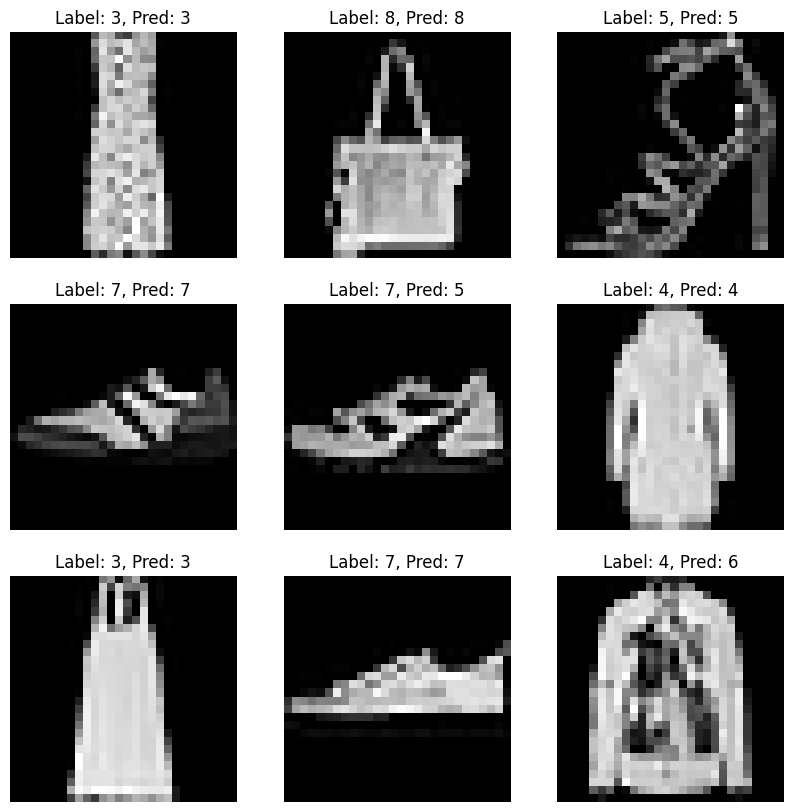

In [ ]:
# Plot predictions
plt.figure(figsize=(10, 10))
for i, (sample, label, pred) in enumerate(zip(test_samples, test_labels, pred_classes)):
  plt.subplot(3, 3, i+1)
  plt.imshow(sample.squeeze(), cmap='gray')
  plt.title(f"Label: {label}, Pred: {pred}")
  plt.axis(False)

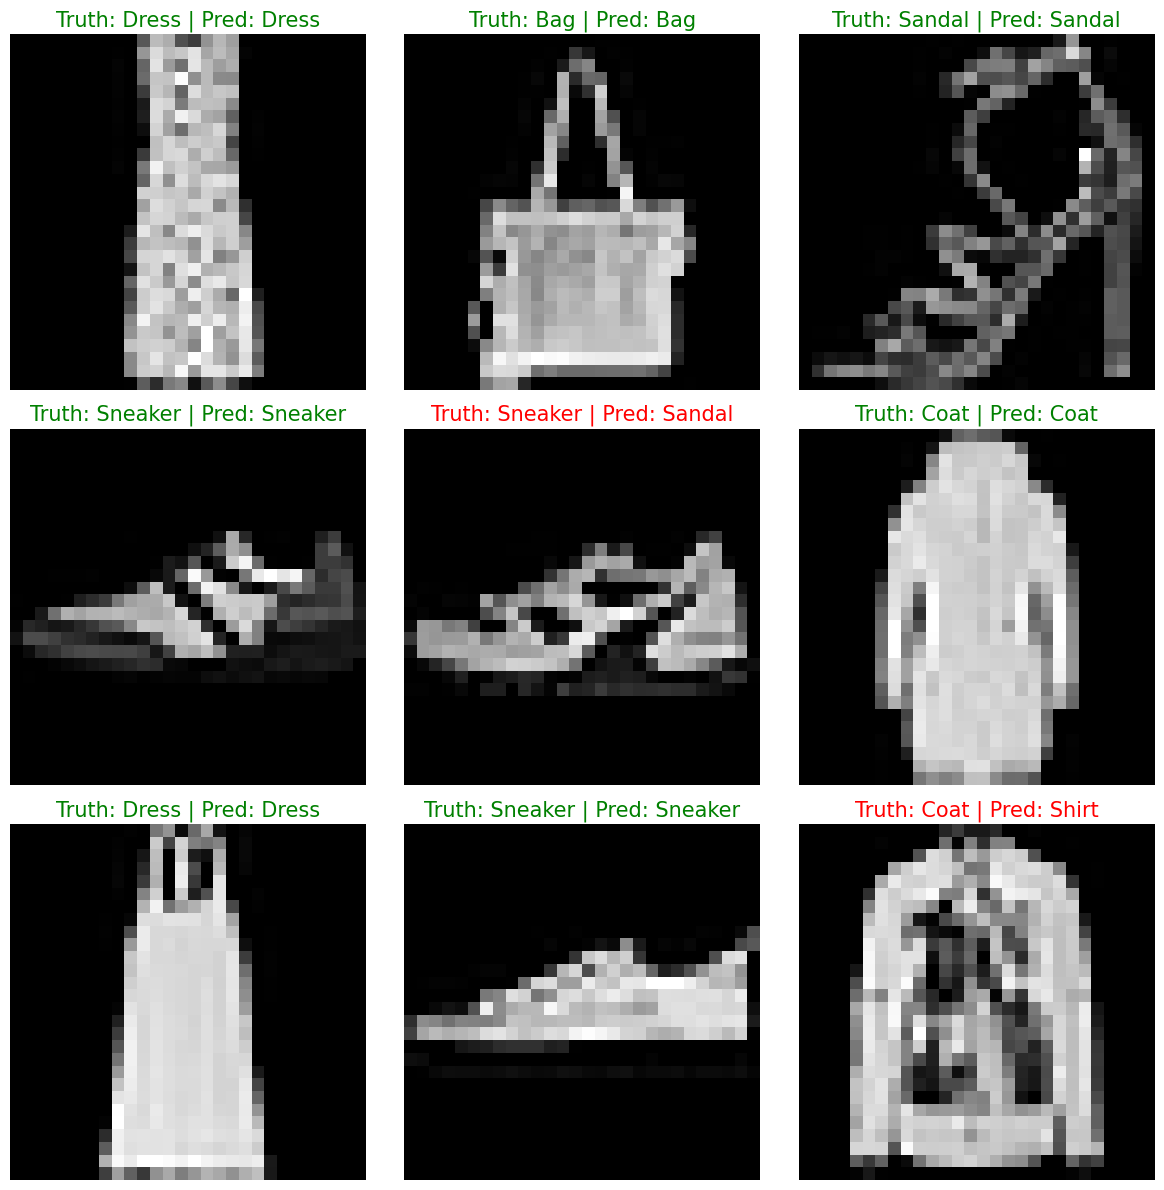

In [ ]:
# Eğer daha önce tanımlamadıysanız:
# class_names = train_data.classes

plt.figure(figsize=(12, 12))

for i, (sample, label, pred) in enumerate(
    zip(test_samples, test_labels, pred_classes)
):
    plt.subplot(3, 3, i + 1)

    # Matplotlib için tensörü CPU'ya alıp boyutları sıkıştırın
    plt.imshow(sample.squeeze().cpu(), cmap="gray")

    # Sayısal indeksten sınıf ismini çekin
    truth_label = class_names[label]
    pred_label = class_names[pred]

    # Başlık metni
    title_text = f"Truth: {truth_label} | Pred: {pred_label}"

    # Tahmin doğruysa yeşil, hatalıysa kırmızı başlık
    if truth_label == pred_label:
        plt.title(title_text, fontsize=15, c="g")
    else:
        plt.title(title_text, fontsize=15, c="r")

    plt.axis(False)

plt.tight_layout()

## 10. Confusion Matrix

Tahminler alınıyor:   0%|          | 0/313 [00:00<?, ?it/s]

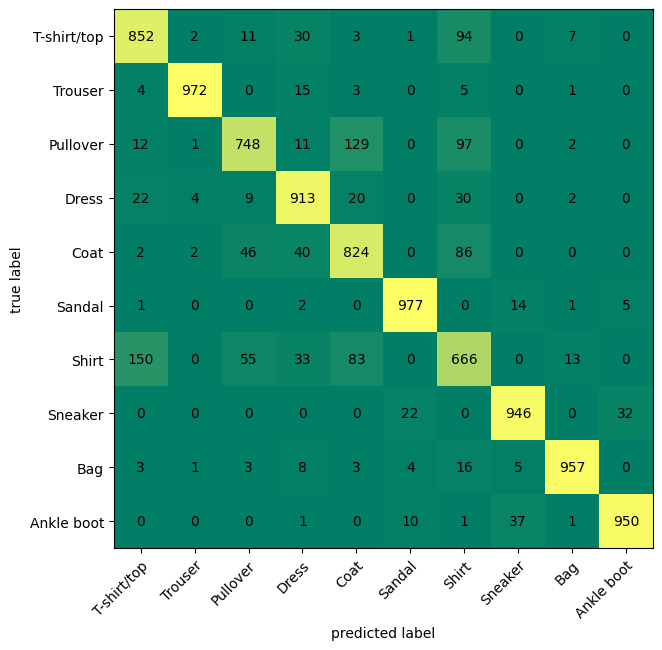

In [ ]:
# 1. Gerekli kütüphaneleri yükleyin (Colab kullanıyorsanız)
# !pip install -q torchmetrics -U mlxtend

import torch
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix
from tqdm.auto import tqdm

# 2. Tüm test seti üzerinde tahminleri toplayın
y_preds = []
model_2.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Tahminler alınıyor"):
        # Veriyi cihaza gönder
        X, y = X.to(device), y.to(device)

        # İleri yayılım ve en yüksek olasılıklı sınıfın seçimi
        y_logit = model_2(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)

        # Matrisi CPU'da çizeceğimiz için tensörleri CPU'ya alıp biriktirin
        y_preds.append(y_pred.cpu())

# Listeyi tek parça büyük bir tensöre dönüştürün (Boyut: [10000])
y_pred_tensor = torch.cat(y_preds)

# 3. Confusion Matrix nesnesini kurun ve hesaplayın
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

# 4. Matrisi görselleştirin
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    fontcolor_threshold=1,
    class_names=class_names,
    figsize=(10, 7),
    cmap='summer'
)

## 11. Save and load best performing model

In [ ]:
from pathlib import Path

# Create model dictory path
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save
MODEL_NAME = 'fashion_mnist_model_2.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save model
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

In [ ]:
# Create a new instance
torch.manual_seed(42)


loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))

# Load in the save state_dict()
loaded_model_2.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Send the model to the target device
loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
# Evaulate loaded model
torch.manual_seed(42)

loaded_model_2_results = test_step(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

loaded_model_2_results

Test loss: 0.32719 | Test accuracy: 88.07%



In [ ]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [ ]:
# Check if model results are close to each other with torch.isclose